In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("Twitter Sentiments.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (31962, 3)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
print("Dataset Information:")
print()

print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:

Shape: (31962, 3)

Column Names:
['id', 'label', 'tweet']

Data Types:
id        int64
label     int64
tweet    object
dtype: object

Missing Values:
id       0
label    0
tweet    0
dtype: int64

Duplicate Rows: 0


Label Distribution:
label
0    29720
1     2242
Name: count, dtype: int64


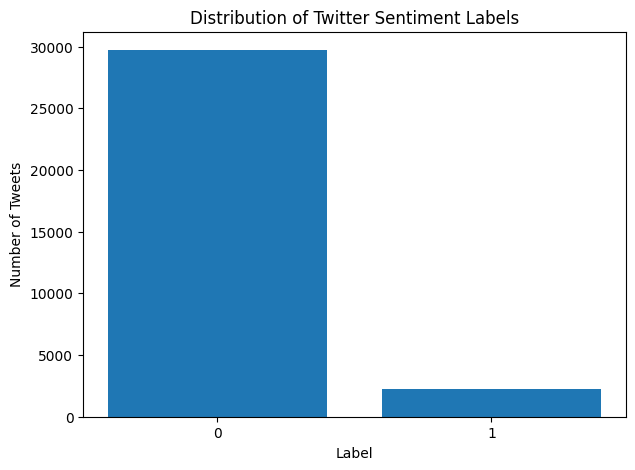

In [ ]:
label_counts = df["label"].value_counts().sort_index()

print("Label Distribution:")
print(label_counts)

plt.figure(figsize=(7, 5))
plt.bar(label_counts.index.astype(str), label_counts.values)

plt.title("Distribution of Twitter Sentiment Labels")
plt.xlabel("Label")
plt.ylabel("Number of Tweets")

plt.show()

In [ ]:
import re

def clean_tweet(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_tweet"] = df["tweet"].apply(clean_tweet)

df[["tweet", "clean_tweet"]].head(10)

,tweet,clean_tweet
0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...
1,@user @user thanks for #lyft credit i can't us...,thanks for lyft credit i cant use cause they d...
2,bihday your majesty,bihday your majesty
3,#model i love u take with u all the time in ...,model i love u take with u all the time in ur
4,factsguide: society now #motivation,factsguide society now motivation
5,[2/2] huge fan fare and big talking before the...,huge fan fare and big talking before they leav...
6,@user camping tomorrow @user @user @user @use...,camping tomorrow danny
7,the next school year is the year for exams.ð...,the next school year is the year for exams can...
8,we won!!! love the land!!! #allin #cavs #champ...,we won love the land allin cavs champions clev...
9,@user @user welcome here ! i'm it's so #gr...,welcome here im its so gr


In [ ]:
from collections import Counter

# Combine all cleaned tweets
all_words = " ".join(df["clean_tweet"]).split()

# Count word frequency
word_counts = Counter(all_words)

# Get the 20 most common words
top_words = word_counts.most_common(20)

print("Top 20 Most Common Words:")
for word, count in top_words:
    print(word, ":", count)

Top 20 Most Common Words:
the : 10199
to : 9844
a : 6468
i : 5766
you : 5456
and : 4896
in : 4663
for : 4498
is : 4187
of : 4180
my : 3692
love : 2726
this : 2666
on : 2653
with : 2522
it : 2505
be : 2474
day : 2290
so : 1970
all : 1941


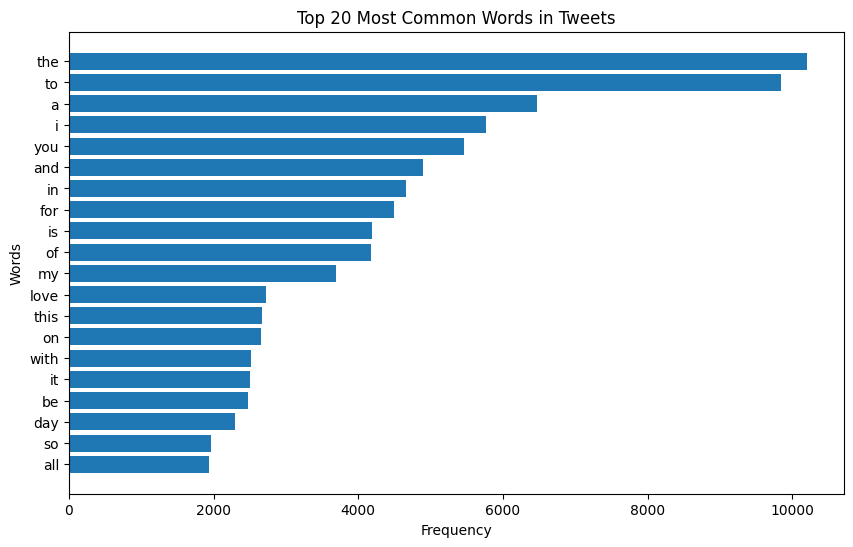

In [ ]:
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Most Common Words in Tweets")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [ ]:
!pip install nltk -q

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
def get_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["tweet"].apply(get_sentiment)

print(df[["tweet", "sentiment"]].head(10))

                                               tweet sentiment
0   @user when a father is dysfunctional and is s...  Negative
1  @user @user thanks for #lyft credit i can't us...  Positive
2                                bihday your majesty   Neutral
3  #model   i love u take with u all the time in ...  Positive
4             factsguide: society now    #motivation   Neutral
5  [2/2] huge fan fare and big talking before the...  Negative
6   @user camping tomorrow @user @user @user @use...   Neutral
7  the next school year is the year for exams.ð...   Neutral
8  we won!!! love the land!!! #allin #cavs #champ...  Positive
9   @user @user welcome here !  i'm   it's so #gr...  Positive


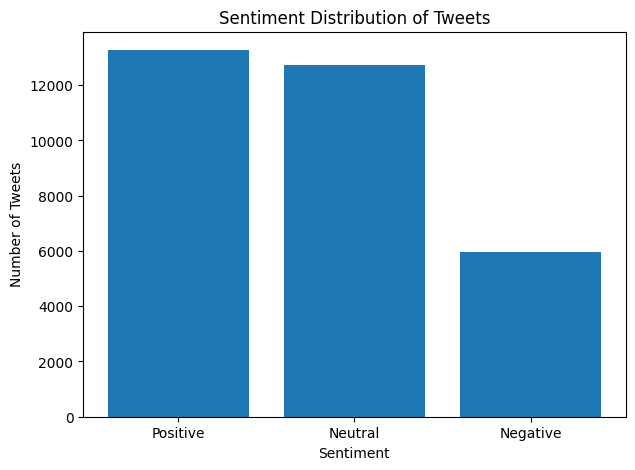

In [ ]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Distribution of Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [ ]:
sentiment_label = pd.crosstab(
    df["label"],
    df["sentiment"]
)

print("Sentiment by Label:")
print(sentiment_label)

Sentiment by Label:
sentiment  Negative  Neutral  Positive
label                                 
0              5091    11964     12665
1               872      765       605


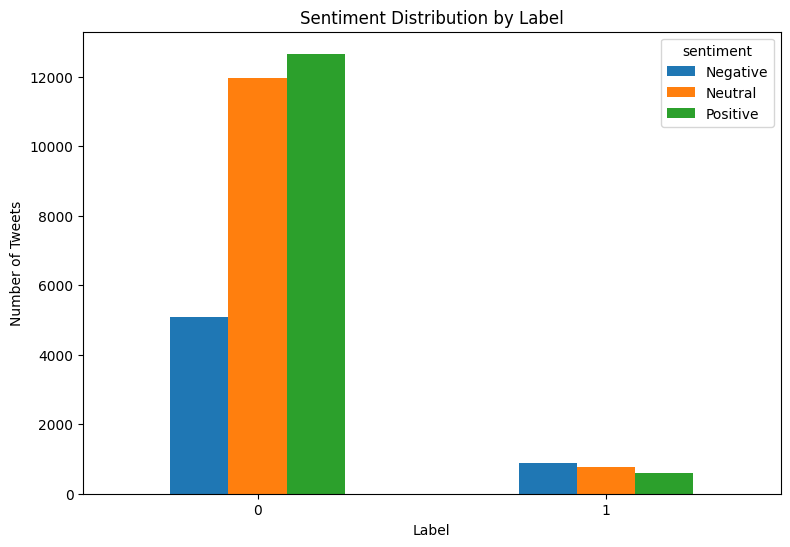

In [ ]:
sentiment_label.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Sentiment Distribution by Label")
plt.xlabel("Label")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)

plt.show()

In [ ]:
sentiment_percentage = pd.crosstab(
    df["label"],
    df["sentiment"],
    normalize="index"
) * 100

print("Sentiment Percentage by Label:")
print(sentiment_percentage.round(2))

Sentiment Percentage by Label:
sentiment  Negative  Neutral  Positive
label                                 
0             17.13    40.26     42.61
1             38.89    34.12     26.98


In [ ]:
df["tweet_length"] = df["tweet"].astype(str).str.len()

print("Average Tweet Length:", round(df["tweet_length"].mean(), 2))
print("Maximum Tweet Length:", df["tweet_length"].max())
print("Minimum Tweet Length:", df["tweet_length"].min())

Average Tweet Length: 84.74
Maximum Tweet Length: 274
Minimum Tweet Length: 11


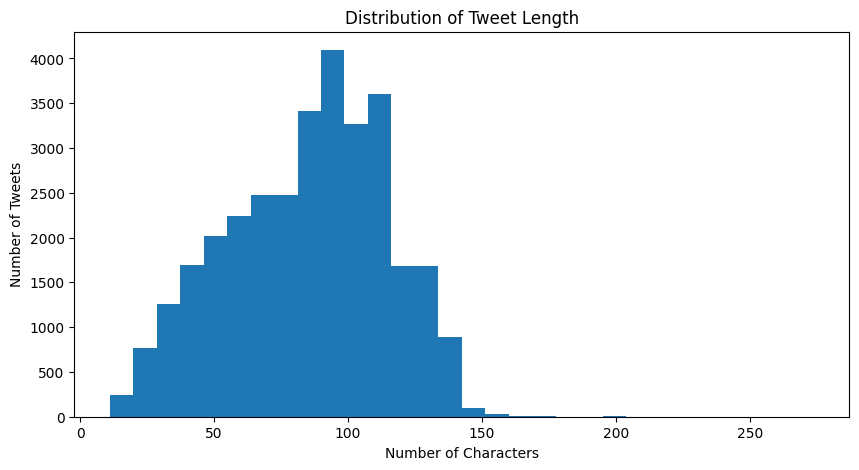

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["tweet_length"], bins=30)

plt.title("Distribution of Tweet Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")

plt.show()

In [ ]:
print("========== TASK 04 SUMMARY ==========")

print("\nDataset Shape:")
print(df.shape)

print("\nLabel Distribution:")
print(df["label"].value_counts())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nAverage Tweet Length:")
print(round(df["tweet_length"].mean(), 2))

print("\nAverage Tweet Length by Label:")
print(df.groupby("label")["tweet_length"].mean().round(2))

========== TASK 04 SUMMARY ==========

Dataset Shape:
(31962, 6)

Label Distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Sentiment Distribution:
sentiment
Positive    13270
Neutral     12729
Negative     5963
Name: count, dtype: int64

Average Tweet Length:
84.74

Average Tweet Length by Label:
label
0    84.33
1    90.19
Name: tweet_length, dtype: float64


## Conclusion

The Twitter dataset was analyzed to identify patterns in tweet content and sentiment.

The analysis included data cleaning, label distribution analysis, word-frequency analysis, sentiment classification, sentiment comparison across labels, and tweet-length analysis.

The visualizations helped identify the distribution of different sentiment categories and common patterns in Twitter content.

Overall, this project demonstrates how Python-based data analysis and visualization techniques can be used to understand public opinion and sentiment patterns in social media data.